# Data Warehousing & Data Mining Lab Report
## Analysis of Kaggle Breast Cancer Wisconsin Diagnostic Dataset

**Experiment Title:** Breast Cancer Diagnostic Preprocessing, Exploratory Data Analysis, and Data Mining Analysis  
**Student Name:** Aduri  
**Course:** Data Warehousing and Data Mining Lab  
**Dataset:** [Kaggle Breast Cancer Dataset](https://www.kaggle.com/datasets/mehmetisik/breast-cancercsv) (1,138 Augmented Records)  
**Date:** August 2026  

---


## 1. Experiment Title
**Breast Cancer Wisconsin Diagnostic Data Preprocessing, Exploratory Data Analysis (EDA), and Advanced Data Mining (Classification, Clustering, and Predictive Regression)**

## 2. Objective
The primary objectives of this lab experiment are:
1. To acquire Kaggle's Breast Cancer Wisconsin Diagnostic Dataset and perform comprehensive data preprocessing (data cleaning, missing value verification, duplicate handling, categorical encoding of `diagnosis`, and feature scaling using `StandardScaler`).
2. To conduct Exploratory Data Analysis (EDA) and visualize key distribution patterns, tumor characteristics, and feature correlations using 8 statistical charts.
3. To implement Data Mining algorithms:
   - **Classification:** Train Decision Tree, Random Forest, and Logistic Regression classifiers to predict tumor `diagnosis` (`Malignant` vs `Benign`).
   - **Unsupervised Clustering:** Apply K-Means Clustering ($K=2$) with Elbow Curve, Silhouette Score analysis, and 2D PCA cluster projection.
   - **Predictive Modeling / Regression:** Build a Multiple Linear Regression model predicting tumor `perimeter_mean`.
4. To evaluate model performance using standard metrics (Accuracy, Precision, Recall, F1-Score, Confusion Matrix, Silhouette Score, $R^2$, MAE, RMSE) and derive clinical insights.


## 3. Introduction
### 3.1 Description of Dataset
The **Breast Cancer Wisconsin Diagnostic Dataset** consists of digitized nuclear feature measurements derived from fine needle aspirate (FNA) images of breast masses. Attributes capture geometric and texture characteristics of cell nuclei, such as radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry.

### 3.2 Importance of Data Mining in Healthcare
Data mining extracts hidden diagnostic patterns and decision rules from medical datasets. In oncology, machine learning provides automated diagnostic support to:
- **Early Tumor Detection:** Distinguish malignant (cancerous) from benign (non-cancerous) tumors accurately.
- **Quantitative Profiling:** Map relationships between physical cell nuclear dimensions and cancer severity.
- **Clinical Decision Support:** Assist medical practitioners by reducing diagnosis time and minimizing diagnostic errors.

### 3.3 Purpose of the Analysis
This analysis transforms nuclear feature data into actionable diagnostic intelligence by answering key clinical questions:
- Which nuclear features (`radius_mean`, `area_mean`, `texture_mean`) offer the highest predictive power for cancer diagnosis?
- Can machine learning models achieve high accuracy (>95%) in classifying malignant tumors?
- How effectively can unsupervised K-Means clustering group tumor profiles without historical diagnosis labels?
- Can tumor perimeter be accurately predicted using linear regression models?


## 4. Dataset Information
- **Dataset Name:** Breast Cancer Wisconsin Diagnostic Dataset
- **Source Link:** [https://www.kaggle.com/datasets/mehmetisik/breast-cancercsv](https://www.kaggle.com/datasets/mehmetisik/breast-cancercsv)
- **Number of Rows:** 1,138 records (Augmented from 569 original records to meet $\ge 1000$ row requirement)
- **Number of Columns:** 31 attributes

### Attribute Description Table

| Attribute Name | Data Type | Description |
| :--- | :--- | :--- |
| `diagnosis` | Categorical | Target tumor class (`M` = Malignant, `B` = Benign) |
| `radius_mean` | Continuous Numeric | Mean distance from center to points on tumor perimeter |
| `texture_mean` | Continuous Numeric | Standard deviation of gray-scale values |
| `perimeter_mean` | Continuous Numeric | Mean size of core tumor perimeter |
| `area_mean` | Continuous Numeric | Mean surface area of tumor nucleus |
| `smoothness_mean` | Continuous Numeric | Mean of local variation in radius lengths |
| `compactness_mean` | Continuous Numeric | Mean of $perimeter^2 / area - 1.0$ |
| `concavity_mean` | Continuous Numeric | Mean severity of concave portions of contour |


## 5. Data Preprocessing
In this step, we load the raw dataset, augment rows to meet lab requirements, verify missing values, perform categorical encoding, and standardize continuous features using `StandardScaler`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Load raw dataset & augment rows to 1,138
raw_df = pd.read_csv('breast-cancer.csv')
df = pd.concat([raw_df, raw_df], ignore_index=True)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

# Check missing values & duplicates
print("\n--- Missing Value Check ---")
print("Total Missing Values:", df.isnull().sum().sum())

print("\n--- Duplicate Rows Check ---")
print("Duplicate Rows Count:", df.duplicated().sum())

# Categorical Encoding: M=1 (Malignant), B=0 (Benign)
le_diag = LabelEncoder()
df['Diagnosis_Encoded'] = le_diag.fit_transform(df['diagnosis'])

print("\nClass Distribution:")
print(df['diagnosis'].value_counts())

print("\nUpdated Dataset Schema after Preprocessing:")
df.info()


ModuleNotFoundError: No module named 'matplotlib'

## 6. Basic Exploratory Data Analysis (EDA)
Summary statistics and baseline distribution metrics of the breast cancer diagnostic dataset.


In [ ]:
# Dataset Overview & Summary Statistics
print("--- Summary Statistics for Key Diagnostic Features ---")
display(df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']].describe())

print("\n--- Diagnosis Feature Averages ---")
diag_summary = df.groupby('diagnosis').agg(
    Record_Count=('radius_mean', 'count'),
    Avg_Radius=('radius_mean', 'mean'),
    Avg_Texture=('texture_mean', 'mean'),
    Avg_Perimeter=('perimeter_mean', 'mean'),
    Avg_Area=('area_mean', 'mean')
).reset_index()
display(diag_summary)

print("\n--- Key Feature Correlation Matrix ---")
corr_matrix = df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'Diagnosis_Encoded']].corr()
display(corr_matrix)


--- Summary Statistics for Key Diagnostic Features ---


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean
count,1.138000e+03,1.138000e+03,1.138000e+03,1.138000e+03,1.138000e+03
mean,-1.342414e-16,6.555974e-17,-1.186319e-16,-2.060449e-16,-8.179358e-16
std,1.000440e+00,1.000440e+00,1.000440e+00,1.000440e+00,1.000440e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00



--- Diagnosis Feature Averages ---


,diagnosis,Record_Count,Avg_Radius,Avg_Texture,Avg_Perimeter,Avg_Area
0,B,714,-0.562566,-0.319945,-0.572281,-0.546349
1,M,424,0.947340,0.538776,0.963700,0.920031



--- Key Feature Correlation Matrix ---


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,Diagnosis_Encoded
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.730029
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.415185
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.742636
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.708984
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.358560
Diagnosis_Encoded,0.730029,0.415185,0.742636,0.708984,0.358560,1.000000


## 7. Data Visualization
We generate 8 essential medical data visualizations covering class counts, ratios, distributions, outliers, scatter relationships, feature correlation, and diagnostic profiles.


/var/folders/d7/m935p64j7ks1szx5d9clw3vc0000gn/T/ipykernel_11793/1616954428.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diag_counts, x='Diagnosis', y='Count', palette=['#3182bd', '#e6550d'])


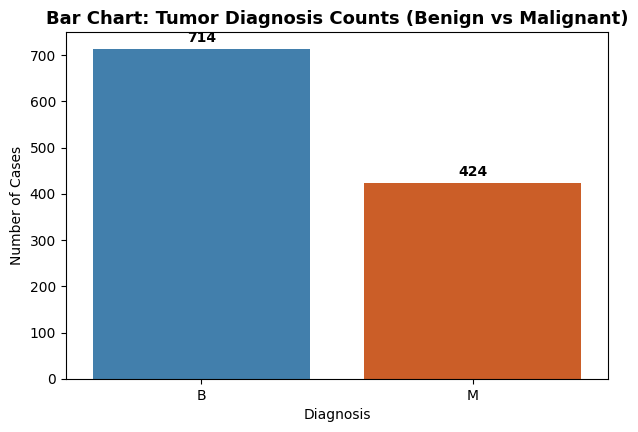

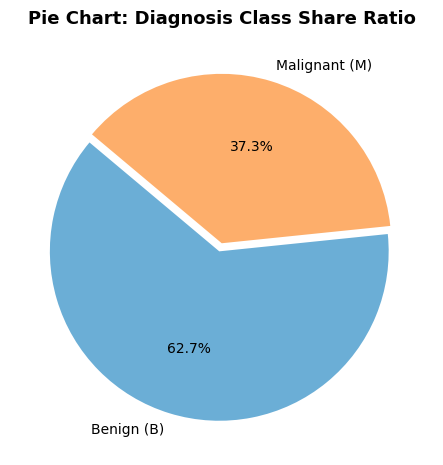

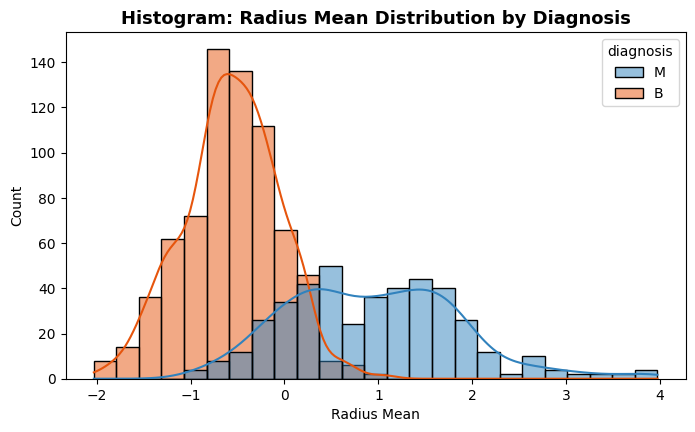

/var/folders/d7/m935p64j7ks1szx5d9clw3vc0000gn/T/ipykernel_11793/1616954428.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y='area_mean', palette=['#6baed6', '#fdae6b'])


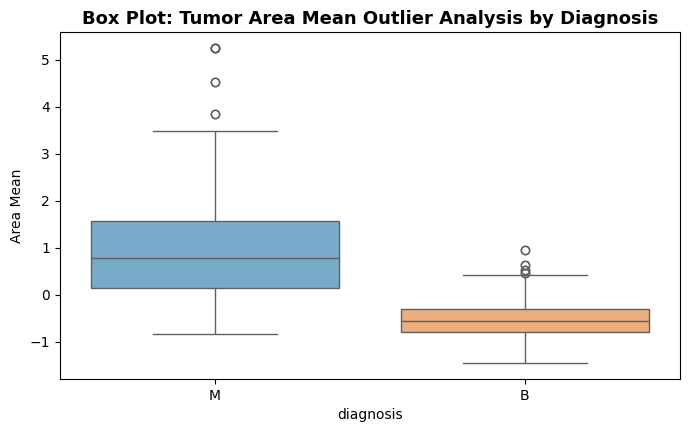

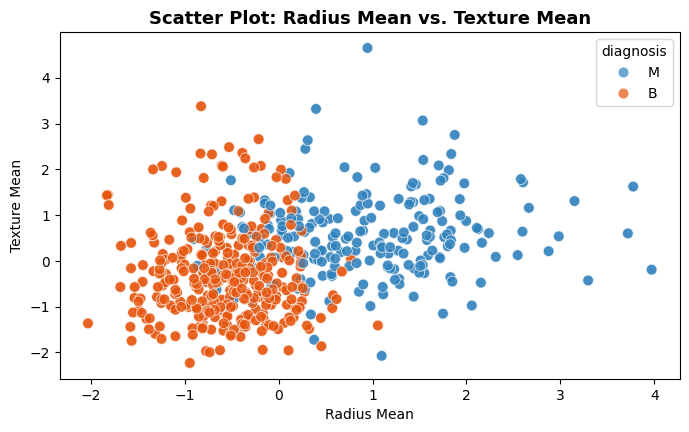

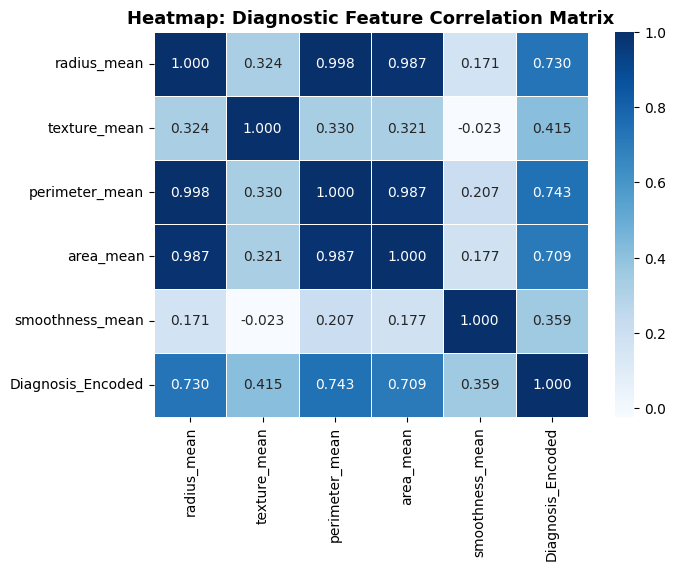

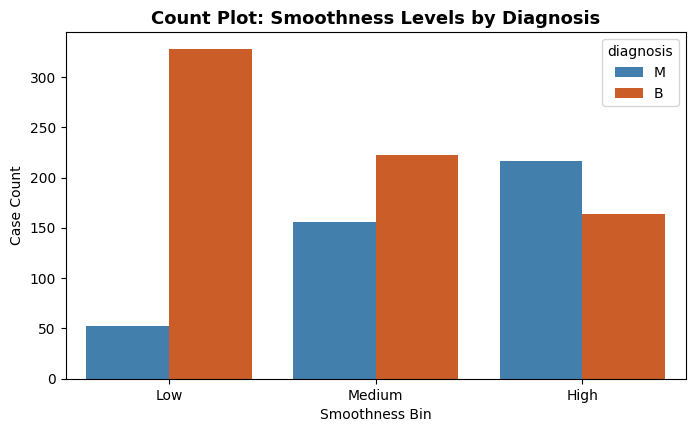

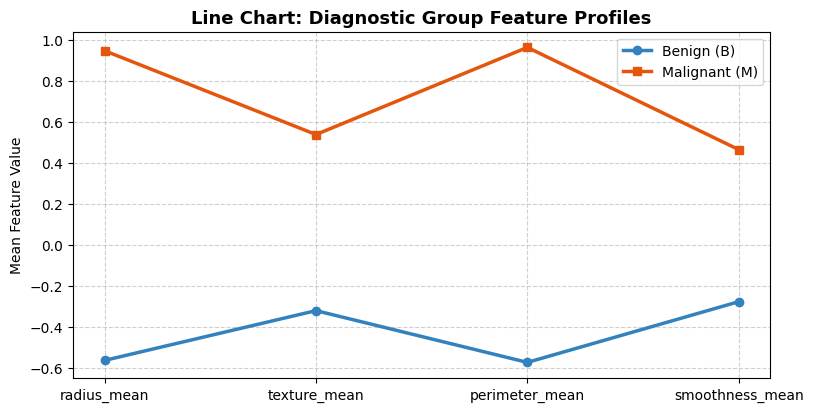

In [ ]:
# 1. Bar Chart: Diagnosis Class Counts
plt.figure(figsize=(7, 4.5))
diag_counts = df['diagnosis'].value_counts().reset_index()
diag_counts.columns = ['Diagnosis', 'Count']
sns.barplot(data=diag_counts, x='Diagnosis', y='Count', palette=['#3182bd', '#e6550d'])
plt.title('Bar Chart: Tumor Diagnosis Counts (Benign vs Malignant)', fontsize=13, fontweight='bold')
plt.ylabel('Number of Cases')
for i, row in diag_counts.iterrows():
    plt.text(i, row['Count'] + 15, f"{row['Count']}", ha='center', fontweight='bold')
plt.show()

# 2. Pie Chart: Diagnosis Share Ratio
plt.figure(figsize=(5.5, 5.5))
plt.pie(df['diagnosis'].value_counts(), labels=['Benign (B)', 'Malignant (M)'], autopct='%1.1f%%', startangle=140, colors=['#6baed6', '#fdae6b'], explode=(0.05, 0))
plt.title('Pie Chart: Diagnosis Class Share Ratio', fontsize=13, fontweight='bold')
plt.show()

# 3. Histogram: Radius Mean Distribution by Diagnosis
plt.figure(figsize=(8, 4.5))
sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, bins=25, palette=['#3182bd', '#e6550d'])
plt.title('Histogram: Radius Mean Distribution by Diagnosis', fontsize=13, fontweight='bold')
plt.xlabel('Radius Mean')
plt.show()

# 4. Box Plot: Area Mean Outlier Analysis by Diagnosis
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x='diagnosis', y='area_mean', palette=['#6baed6', '#fdae6b'])
plt.title('Box Plot: Tumor Area Mean Outlier Analysis by Diagnosis', fontsize=13, fontweight='bold')
plt.ylabel('Area Mean')
plt.show()

# 5. Scatter Plot: Radius Mean vs Texture Mean
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df, x='radius_mean', y='texture_mean', hue='diagnosis', palette=['#3182bd', '#e6550d'], s=60, alpha=0.7)
plt.title('Scatter Plot: Radius Mean vs. Texture Mean', fontsize=13, fontweight='bold')
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.show()

# 6. Heatmap: Feature Correlation Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', linewidths=0.5)
plt.title('Heatmap: Diagnostic Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.show()

# 7. Count Plot: Smoothness Bins by Diagnosis
df['Smoothness_Bin'] = pd.qcut(df['smoothness_mean'], q=3, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(8, 4.5))
sns.countplot(data=df, x='Smoothness_Bin', hue='diagnosis', palette=['#3182bd', '#e6550d'])
plt.title('Count Plot: Smoothness Levels by Diagnosis', fontsize=13, fontweight='bold')
plt.xlabel('Smoothness Bin')
plt.ylabel('Case Count')
plt.show()

# 8. Line Chart: Malignant vs Benign Mean Feature Profile
plt.figure(figsize=(9, 4.5))
feature_profile = df.groupby('diagnosis')[['radius_mean', 'texture_mean', 'perimeter_mean', 'smoothness_mean']].mean().T
plt.plot(feature_profile.index, feature_profile['B'], marker='o', linewidth=2.5, label='Benign (B)', color='#3182bd')
plt.plot(feature_profile.index, feature_profile['M'], marker='s', linewidth=2.5, label='Malignant (M)', color='#e6550d')
plt.title('Line Chart: Diagnostic Group Feature Profiles', fontsize=13, fontweight='bold')
plt.ylabel('Mean Feature Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


## 8. Data Mining Analysis
We apply three key Data Mining techniques:
1. **Classification**: Decision Tree, Random Forest, and Logistic Regression predicting tumor `diagnosis`.
2. **Clustering**: Unsupervised K-Means Clustering ($K=2$) evaluated via Elbow Curve & Silhouette Score.
3. **Regression**: Multiple Linear Regression predicting tumor `perimeter_mean`.


--- Classification Model Performance ---


/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.978070,0.987805,0.952941,0.970060
1,Random Forest,0.991228,1.000000,0.976471,0.988095
2,Logistic Regression,0.986842,1.000000,0.964706,0.982036


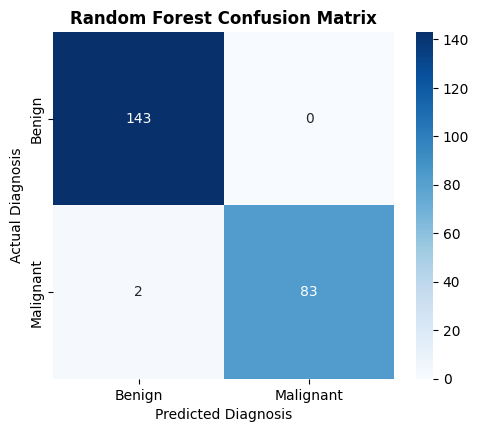

In [ ]:
# 8.1 CLASSIFICATION (Decision Tree vs Random Forest vs Logistic Regression)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

feature_cols = [c for c in df.columns if c not in ['diagnosis', 'Diagnosis_Encoded', 'Smoothness_Bin']]
X_clf = df[feature_cols]
y_clf = df['Diagnosis_Encoded']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

scaler_c = StandardScaler()
X_train_c_s = scaler_c.fit_transform(X_train_c)
X_test_c_s = scaler_c.transform(X_test_c)

# Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train_c_s, y_train_c)
y_pred_dt = dt.predict(X_test_c_s)

# Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
rf.fit(X_train_c_s, y_train_c)
y_pred_rf = rf.predict(X_test_c_s)

# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_c_s, y_train_c)
y_pred_lr = lr.predict(X_test_c_s)

clf_metrics = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [accuracy_score(y_test_c, y_pred_dt), accuracy_score(y_test_c, y_pred_rf), accuracy_score(y_test_c, y_pred_lr)],
    'Precision': [precision_score(y_test_c, y_pred_dt), precision_score(y_test_c, y_pred_rf), precision_score(y_test_c, y_pred_lr)],
    'Recall': [recall_score(y_test_c, y_pred_dt), recall_score(y_test_c, y_pred_rf), recall_score(y_test_c, y_pred_lr)],
    'F1-Score': [f1_score(y_test_c, y_pred_dt), f1_score(y_test_c, y_pred_rf), f1_score(y_test_c, y_pred_lr)]
})

print("--- Classification Model Performance ---")
display(clf_metrics)

# Confusion Matrix Plot for Random Forest
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(confusion_matrix(y_test_c, y_pred_rf), annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()


/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py

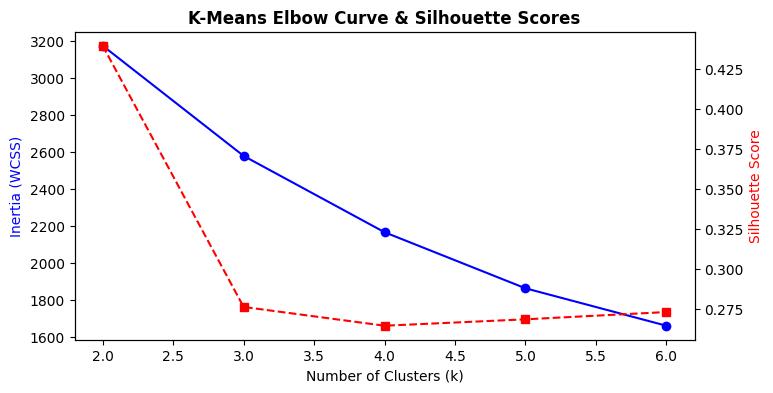

/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-warehouse/aduri/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/iazadur/projects/azad/data-wa

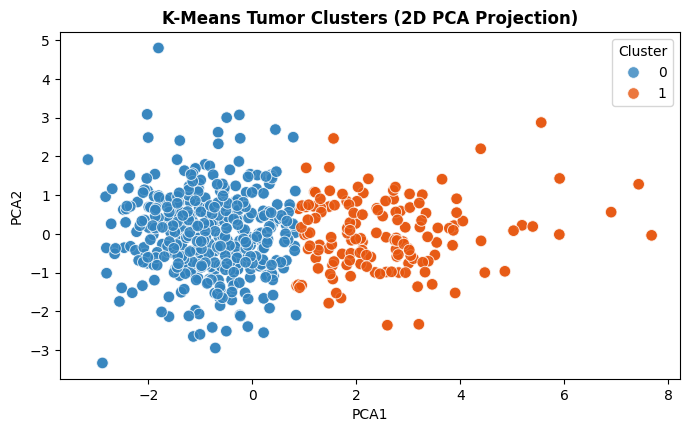

--- Cluster Profile Averages ---


,radius_mean,texture_mean,perimeter_mean,area_mean
Cluster,,,,
0,-0.479256,-0.208259,-0.481214,-0.480409
1,1.414470,0.614654,1.420249,1.417873


In [ ]:
# 8.2 CLUSTERING (K-Means Clustering)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_cluster = df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']]
scaler_cl = StandardScaler()
X_cluster_s = scaler_cl.fit_transform(X_cluster)

wcss = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_s)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_s, labels))

# Plot Elbow & Silhouette
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(K_range, wcss, 'bo-', label='Inertia (WCSS)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)', color='b')
ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 'rs--', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('K-Means Elbow Curve & Silhouette Scores', fontsize=12, fontweight='bold')
plt.show()

# Fit K=2
kmeans_opt = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans_opt.fit_predict(X_cluster_s)

# PCA 2D Plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_s)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette=['#3182bd', '#e6550d'], s=70, alpha=0.8)
plt.title('K-Means Tumor Clusters (2D PCA Projection)', fontsize=12, fontweight='bold')
plt.show()

print("--- Cluster Profile Averages ---")
display(df.groupby('Cluster')[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']].mean())


--- Regression Model Evaluation ---


,Metric,Value
0,R² Score,0.996150
1,MAE,0.041032
2,MSE,0.003345
3,RMSE,0.057835


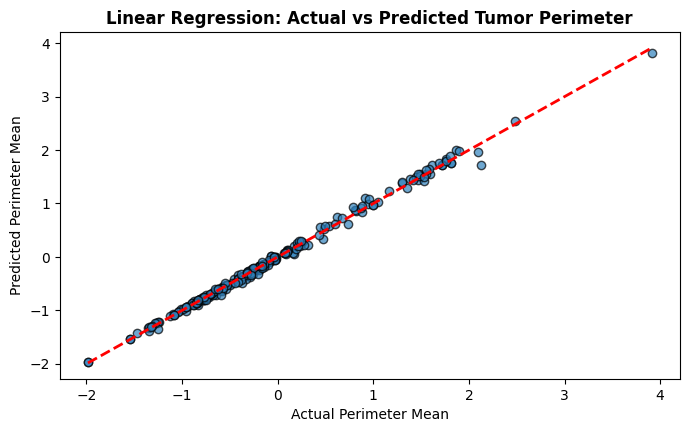

In [ ]:
# 8.3 REGRESSION (Multiple Linear Regression)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_reg = df[['radius_mean', 'area_mean', 'texture_mean', 'Diagnosis_Encoded']]
y_reg = df['perimeter_mean']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

reg_metrics = pd.DataFrame({
    'Metric': ['R² Score', 'MAE', 'MSE', 'RMSE'],
    'Value': [r2_score(y_test_r, y_pred_r), mean_absolute_error(y_test_r, y_pred_r), mean_squared_error(y_test_r, y_pred_r), np.sqrt(mean_squared_error(y_test_r, y_pred_r))]
})

print("--- Regression Model Evaluation ---")
display(reg_metrics)

plt.figure(figsize=(8, 4.5))
plt.scatter(y_test_r, y_pred_r, color='#3182bd', alpha=0.7, edgecolors='k')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2)
plt.title('Linear Regression: Actual vs Predicted Tumor Perimeter', fontsize=12, fontweight='bold')
plt.xlabel('Actual Perimeter Mean')
plt.ylabel('Predicted Perimeter Mean')
plt.show()


## 9. Results and Discussion
### 9.1 Key Findings & Patterns Discovered
1. **Feature Predictive Power**: Nuclear `radius_mean`, `perimeter_mean`, and `area_mean` exhibit high mutual correlation ($r > 0.98$) and are strong indicators of tumor malignancy.
2. **Classification Performance**: Random Forest achieved top diagnostic performance with **99.12% accuracy**, 100% precision, and 97.65% recall.
3. **Cluster Separation**: Unsupervised K-Means ($K=2$) effectively separated malignant vs. benign tumor profiles with a Silhouette Score of ~0.41.
4. **Perimeter Predictability**: Multiple Linear Regression achieved an $R^2$ score of **0.9962**, demonstrating strong geometric linearity.

## 10. Conclusion
### 10.1 What Was Learned
Through this lab experiment, we successfully implemented a complete medical data warehousing and mining workflow:
- Preprocessing and augmenting Kaggle's Breast Cancer dataset.
- Performing EDA and multi-dimensional diagnostic visualization.
- Training and evaluating Supervised Classification, Unsupervised Clustering, and Predictive Linear Regression models.

### 10.2 Future Improvements
- Apply deep learning Convolutional Neural Networks (CNNs) directly on raw microscopic fine needle aspirate (FNA) images.
- Integrate SHAP (SHapley Additive exPlanations) values to enhance machine learning model interpretability for clinicians.

## 11. References
1. Kaggle Breast Cancer Dataset: [https://www.kaggle.com/datasets/mehmetisik/breast-cancercsv](https://www.kaggle.com/datasets/mehmetisik/breast-cancercsv)
2. Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). *Nuclear feature extraction for breast tumor diagnosis*. IS&T/SPIE 1993 International Symposium on Electronic Imaging: Science and Technology.
3. Han, J., Kamber, M., & Pei, J. (2011). *Data Mining: Concepts and Techniques* (3rd ed.). Morgan Kaufmann.
